## 4. Modeling

This notebook trains, evaluates, tunes, and selects the best regression model for predicting concrete compressive strength. It uses the retained engineered feature set created in 03_feature_engineering.ipynb and compares required default models, cross-validation performance, and tuned models before saving the final winner.

In [19]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error

### 4.1 Load Data

03_feature_engineering.ipynb exported the final modeling artifacts as a single **joblib bundle** rather than four separate CSV files. This was done for reproducibility and convenience, and the bundle contains the same saved train/test modeling inputs that would otherwise be loaded as separate files, including the retained engineered feature sets, scaled versions, target vectors, and fitted scaler.

In [20]:
bundle_path = "/content/team6_feature_engineering.joblib"
feature_bundle = joblib.load(bundle_path)

X_train_unscaled = feature_bundle["X_train_fe_pruned"].copy()
X_test_unscaled = feature_bundle["X_test_fe_pruned"].copy()

X_train_scaled = feature_bundle["X_train_fe_pruned_scaled"].copy()
X_test_scaled = feature_bundle["X_test_fe_pruned_scaled"].copy()

y_train = feature_bundle["y_train"].copy()
y_test = feature_bundle["y_test"].copy()

feature_names = X_train_unscaled.columns.tolist()

assert X_train_unscaled.columns.tolist() == X_test_unscaled.columns.tolist(), "Unscaled train/test columns do not align."
assert X_train_scaled.columns.tolist() == X_test_scaled.columns.tolist(), "Scaled train/test columns do not align."
assert X_train_unscaled.columns.tolist() == X_train_scaled.columns.tolist(), "Scaled and unscaled feature columns do not match."

print("Unscaled train shape:", X_train_unscaled.shape)
print("Unscaled test shape: ", X_test_unscaled.shape)
print("Scaled train shape:  ", X_train_scaled.shape)
print("Scaled test shape:   ", X_test_scaled.shape)

print("\nTarget range:")
print(f"Min target: {y_train.min():.2f}")
print(f"Max target: {y_train.max():.2f}")

print("\nNumber of retained features:", len(feature_names))
print("First 10 features:", feature_names[:10])

Unscaled train shape: (804, 29)
Unscaled test shape:  (201, 29)
Scaled train shape:   (804, 29)
Scaled test shape:    (201, 29)

Target range:
Min target: 2.33
Max target: 82.60

Number of retained features: 29
First 10 features: ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'total_binder', 'water_cement_ratio']


### Load Data Summary

The retained engineered feature set contains **29 predictors**. The training set has **804 rows** and the test set has **201 rows**. Concrete compressive strength in the saved split ranges from approximately **2.33 MPa to 82.60 MPa**.

For model evaluation, **Linear Regression, Ridge Regression, and Lasso Regression** use the scaled feature set, while **Decision Tree, Random Forest, and Gradient Boosting** use the unscaled feature set. For cross-validation and GridSearchCV, scaled models are evaluated inside pipelines so scaling is learned separately within each fold.

### 4.2 All Models — Default Parameters

Each required regression model is trained with default or guideline-specified baseline settings. Training and test metrics are printed side by side to check for overfitting. Every result is appended to one shared results list for later comparison.

In [21]:
results = []
fitted_models = {}

def evaluate_regression_model(name, model, X_train_used, X_test_used, y_train, y_test):
    model.fit(X_train_used, y_train)

    y_train_pred = model.predict(X_train_used)
    y_test_pred = model.predict(X_test_used)

    result = {
        "Model": name,
        "R2 Train": r2_score(y_train, y_train_pred),
        "RMSE Train": root_mean_squared_error(y_train, y_train_pred),
        "R2 Test": r2_score(y_test, y_test_pred),
        "RMSE Test": root_mean_squared_error(y_test, y_test_pred),
    }

    results.append(result)

    fitted_models[name] = {
        "model": model,
        "X_test": X_test_used.copy(),
        "y_test_pred": y_test_pred.copy()
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"R2 Train:   {result['R2 Train']:.4f}")
    print(f"R2 Test:    {result['R2 Test']:.4f}")
    print(f"RMSE Train: {result['RMSE Train']:.4f}")
    print(f"RMSE Test:  {result['RMSE Test']:.4f}")

    return result

In [22]:
default_models = [
    ("Linear Regression (Unscaled)", LinearRegression(), X_train_unscaled, X_test_unscaled),
    ("Linear Regression (Scaled)", LinearRegression(), X_train_scaled, X_test_scaled),
    ("Ridge Regression", Ridge(alpha=1.0), X_train_scaled, X_test_scaled),
    ("Lasso Regression", Lasso(alpha=0.01, max_iter=20000, random_state=4950), X_train_scaled, X_test_scaled),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=4950), X_train_unscaled, X_test_unscaled),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=4950, n_jobs=-1), X_train_unscaled, X_test_unscaled),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=4950), X_train_unscaled, X_test_unscaled),
]

for name, model, X_train_used, X_test_used in default_models:
    evaluate_regression_model(name, model, X_train_used, X_test_used, y_train, y_test)


Linear Regression (Unscaled)
----------------------------
R2 Train:   0.8612
R2 Test:    0.8426
RMSE Train: 6.1150
RMSE Test:  6.2306

Linear Regression (Scaled)
--------------------------
R2 Train:   0.8616
R2 Test:    0.8425
RMSE Train: 6.1066
RMSE Test:  6.2341

Ridge Regression
----------------
R2 Train:   0.8595
R2 Test:    0.8379
RMSE Train: 6.1527
RMSE Test:  6.3244

Lasso Regression
----------------
R2 Train:   0.8584
R2 Test:    0.8361
RMSE Train: 6.1773
RMSE Test:  6.3583

Decision Tree
-------------
R2 Train:   0.9879
R2 Test:    0.7872
RMSE Train: 1.8033
RMSE Test:  7.2455

Random Forest
-------------
R2 Train:   0.9843
R2 Test:    0.9128
RMSE Train: 2.0567
RMSE Test:  4.6392

Gradient Boosting
-----------------
R2 Train:   0.9627
R2 Test:    0.9201
RMSE Train: 3.1691
RMSE Test:  4.4399


,Model,R2 Train,RMSE Train,R2 Test,RMSE Test
0,Gradient Boosting,0.962732,3.169126,0.920088,4.439927
1,Random Forest,0.984304,2.056674,0.912752,4.639236
2,Linear Regression (Unscaled),0.861248,6.114971,0.842632,6.230564
3,Linear Regression (Scaled),0.861629,6.106561,0.842452,6.234112
4,Ridge Regression,0.859529,6.152716,0.837856,6.324400
5,Lasso Regression,0.858405,6.177296,0.836110,6.358350
6,Decision Tree,0.987933,1.803303,0.787187,7.245489


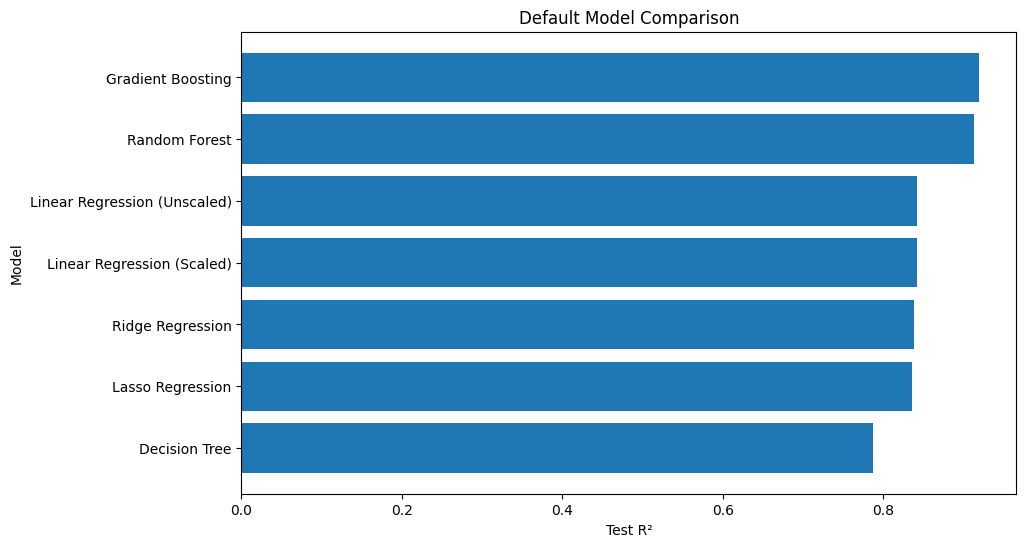

In [23]:
default_results_df = (
    pd.DataFrame(results)
    .sort_values("R2 Test", ascending=False)
    .reset_index(drop=True)
)

display(default_results_df)

plt.figure(figsize=(10, 6))
plt.barh(default_results_df["Model"], default_results_df["R2 Test"])
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Default Model Comparison")
plt.gca().invert_yaxis()
plt.show()

### Default Model Interpretation

Among the default models, Gradient Boosting was the strongest performer with a test-set R² of 0.9201 and RMSE of 4.4399. Random Forest ranked second with a test-set R² of 0.9128 and RMSE of 4.6392. The linear models performed similarly to one another, with test-set R² values around 0.84.

The clearest overfitting pattern was observed in the Decision Tree. Its training R² was 0.9879, but its test R² dropped to 0.7872, indicating that it fit the training data much better than unseen data. Based on the default results, Ridge Regression, Random Forest, and Gradient Boosting were selected for hyperparameter tuning.

### 4.3 Cross-Validation

A single `KFold` object is reused for every model. Scaled models are evaluated in pipelines so scaling occurs inside each fold, which keeps the cross-validation process leakage-safe.


Linear Regression (Unscaled)
----------------------------
Fold scores: [0.8474 0.8373 0.8308 0.8828 0.8482]
CV Mean: 0.8493
CV Std:  0.0180

Linear Regression (Scaled)
--------------------------
Fold scores: [0.8479 0.8342 0.8318 0.8836 0.8488]
CV Mean: 0.8492
CV Std:  0.0185

Ridge Regression
----------------
Fold scores: [0.8501 0.8369 0.8358 0.8832 0.8436]
CV Mean: 0.8499
CV Std:  0.0174

Lasso Regression
----------------
Fold scores: [0.8507 0.8347 0.8344 0.8831 0.8427]
CV Mean: 0.8492
CV Std:  0.0180

Decision Tree
-------------
Fold scores: [0.8039 0.8433 0.8111 0.807  0.8048]
CV Mean: 0.8140
CV Std:  0.0149

Random Forest
-------------
Fold scores: [0.9013 0.8868 0.8783 0.9171 0.8893]
CV Mean: 0.8946
CV Std:  0.0134

Gradient Boosting
-----------------
Fold scores: [0.9068 0.9124 0.882  0.9406 0.9143]
CV Mean: 0.9112
CV Std:  0.0187


,Model,CV Mean,CV Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Gradient Boosting,0.911209,0.018696,0.906825,0.912370,0.881969,0.940579,0.914301
1,Random Forest,0.894563,0.013434,0.901290,0.886839,0.878317,0.917056,0.889311
2,Ridge Regression,0.849923,0.017424,0.850133,0.836868,0.835796,0.883210,0.843605
3,Linear Regression (Unscaled),0.849300,0.017961,0.847385,0.837334,0.830816,0.882814,0.848151
4,Linear Regression (Scaled),0.849236,0.018535,0.847869,0.834165,0.831752,0.883627,0.848767
5,Lasso Regression,0.849152,0.018018,0.850711,0.834749,0.834423,0.883140,0.842735
6,Decision Tree,0.814027,0.014854,0.803893,0.843313,0.811112,0.807031,0.804784


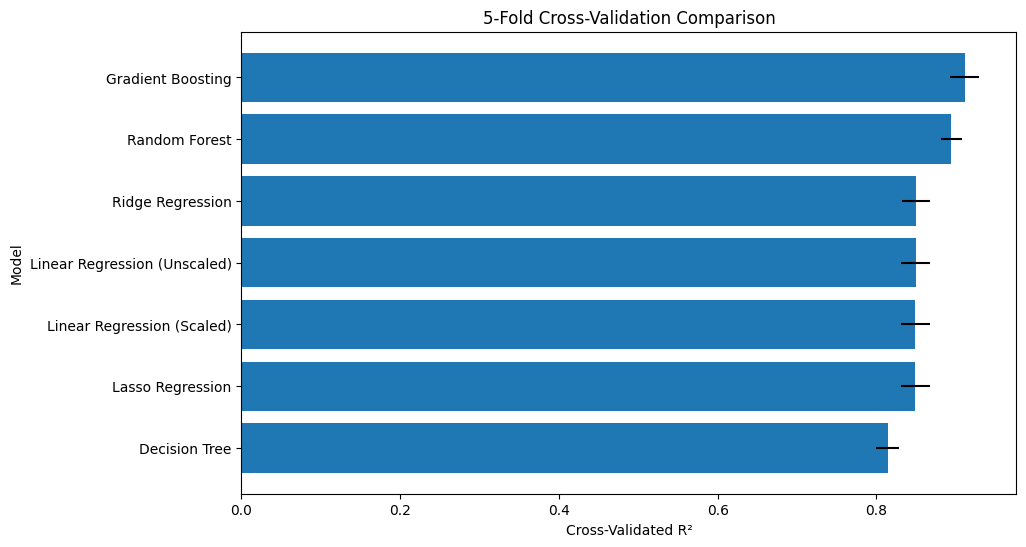

In [24]:
cv_5 = KFold(n_splits=5, shuffle=True, random_state=4950)

cv_models = {
    "Linear Regression (Unscaled)": (LinearRegression(), X_train_unscaled),
    "Linear Regression (Scaled)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        X_train_unscaled
    ),
    "Ridge Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),
        X_train_unscaled
    ),
    "Lasso Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=0.01, max_iter=20000, random_state=4950))
        ]),
        X_train_unscaled
    ),
    "Decision Tree": (
        DecisionTreeRegressor(max_depth=10, random_state=4950),
        X_train_unscaled
    ),
    "Random Forest": (
        RandomForestRegressor(n_estimators=100, random_state=4950, n_jobs=-1),
        X_train_unscaled
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=4950),
        X_train_unscaled
    ),
}

cv_rows = []

for name, (model, X_used) in cv_models.items():
    scores = cross_val_score(model, X_used, y_train, cv=cv_5, scoring="r2", n_jobs=-1)

    row = {
        "Model": name,
        "CV Mean": scores.mean(),
        "CV Std": scores.std(),
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
    }
    cv_rows.append(row)

    print(f"\n{name}")
    print("-" * len(name))
    print("Fold scores:", np.round(scores, 4))
    print(f"CV Mean: {scores.mean():.4f}")
    print(f"CV Std:  {scores.std():.4f}")

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV Mean", ascending=False).reset_index(drop=True)
display(cv_results_df)

plt.figure(figsize=(10, 6))
plt.barh(cv_results_df["Model"], cv_results_df["CV Mean"], xerr=cv_results_df["CV Std"])
plt.xlabel("Cross-Validated R²")
plt.ylabel("Model")
plt.title("5-Fold Cross-Validation Comparison")
plt.gca().invert_yaxis()
plt.show()

### Cross-Validation Interpretation

The cross-validation results were consistent with the default test-set results. Gradient Boosting had the highest CV mean R² at 0.9112, followed by Random Forest at 0.8946, while the linear models clustered near 0.85 and Decision Tree ranked last at 0.8140. This generally agrees with the ranking observed on the held-out test set, which suggests that the model comparison is stable rather than being driven by one favorable split.

No model had a CV standard deviation greater than 0.03. The largest CV standard deviation was still below that threshold, so none of the models were flagged as unstable.

### 4.4 Hyperparameter Tuning — GridSearchCV

The three tuned models in this section are Ridge Regression, Random Forest, and Gradient Boosting. These models were selected because they either showed strong default performance or are specifically required and efficient to tune for regression.

In [25]:
def run_grid_search(name, estimator, param_grid, X_train_used, X_test_used):
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="r2",
        cv=cv_5,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train_used, y_train)

    cv_results = pd.DataFrame(grid.cv_results_)
    top_5 = (
        cv_results[["rank_test_score", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score", "params"]]
        .sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])
        .head(5)
        .reset_index(drop=True)
    )

    print(f"\n{name}")
    print("-" * len(name))
    print("Best parameters:")
    print(grid.best_params_)
    print(f"\nBest CV Mean R²: {grid.best_score_:.4f}")
    print(f"Best CV Std:     {top_5.loc[0, 'std_test_score']:.4f}")
    print("\nTop 5 parameter combinations:")
    display(top_5)

    best_model = grid.best_estimator_
    evaluate_regression_model(name, best_model, X_train_used, X_test_used, y_train, y_test)

    fitted_models[name]["grid_search"] = grid
    fitted_models[name]["best_params"] = grid.best_params_

    return grid, top_5

In [26]:
ridge_estimator = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid, ridge_top5 = run_grid_search(
    name="Ridge Regression (Tuned)",
    estimator=ridge_estimator,
    param_grid=ridge_param_grid,
    X_train_used=X_train_unscaled,
    X_test_used=X_test_unscaled
)


Ridge Regression (Tuned)
------------------------
Best parameters:
{'model__alpha': 1}

Best CV Mean R²: 0.8499
Best CV Std:     0.0174

Top 5 parameter combinations:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
0,1,0.849923,0.017424,0.860305,0.004199,{'model__alpha': 1}
1,2,0.849728,0.018281,0.862207,0.004100,{'model__alpha': 0.1}
2,3,0.849381,0.018045,0.862453,0.004047,{'model__alpha': 0.01}
3,4,0.849309,0.017971,0.862459,0.004046,{'model__alpha': 0.001}
4,5,0.845295,0.015709,0.853498,0.003923,{'model__alpha': 10}



Ridge Regression (Tuned)
------------------------
R2 Train:   0.8595
R2 Test:    0.8379
RMSE Train: 6.1527
RMSE Test:  6.3244


In [27]:
rf_estimator = RandomForestRegressor(random_state=4950, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2", None]
}

rf_grid, rf_top5 = run_grid_search(
    name="Random Forest (Tuned)",
    estimator=rf_estimator,
    param_grid=rf_param_grid,
    X_train_used=X_train_unscaled,
    X_test_used=X_test_unscaled
)


Random Forest (Tuned)
---------------------
Best parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}

Best CV Mean R²: 0.9051
Best CV Std:     0.0138

Top 5 parameter combinations:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
0,1,0.905072,0.013791,0.984597,0.001296,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e..."
1,2,0.904952,0.013650,0.984601,0.001306,"{'max_depth': None, 'max_features': 'sqrt', 'n..."
2,3,0.904315,0.013723,0.984601,0.001264,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e..."
3,4,0.904172,0.013698,0.984601,0.001278,"{'max_depth': None, 'max_features': 'sqrt', 'n..."
4,5,0.904164,0.013368,0.984775,0.001163,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e..."



Random Forest (Tuned)
---------------------
R2 Train:   0.9855
R2 Test:    0.9226
RMSE Train: 1.9782
RMSE Test:  4.3690


In [28]:
gbr_estimator = GradientBoostingRegressor(random_state=4950)

gbr_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gbr_grid, gbr_top5 = run_grid_search(
    name="Gradient Boosting (Tuned)",
    estimator=gbr_estimator,
    param_grid=gbr_param_grid,
    X_train_used=X_train_unscaled,
    X_test_used=X_test_unscaled
)


Gradient Boosting (Tuned)
-------------------------
Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}

Best CV Mean R²: 0.9230
Best CV Std:     0.0192

Top 5 parameter combinations:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
0,1,0.922955,0.019165,0.989903,0.001564,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,2,0.921767,0.019744,0.983225,0.001681,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
2,3,0.918746,0.017370,0.990007,0.001789,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est..."
3,4,0.918104,0.017914,0.976428,0.002168,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
4,5,0.917877,0.018298,0.971499,0.002053,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."



Gradient Boosting (Tuned)
-------------------------
R2 Train:   0.9873
R2 Test:    0.9331
RMSE Train: 1.8497
RMSE Test:  4.0616


### Tuning Interpretation

Hyperparameter tuning improved both Random Forest and Gradient Boosting. Random Forest (Tuned) increased test-set R² from 0.9128 to 0.9226 and reduced RMSE from 4.6392 to 4.3690. Gradient Boosting (Tuned) produced the best overall result, increasing test-set R² from 0.9201 to 0.9331 and reducing RMSE from 4.4399 to 4.0616.

Ridge Regression did not improve with tuning. Its best alpha remained 1, and its tuned test performance matched the default result exactly. For that reason, Ridge Regression was kept in the notebook as a tuned comparison, but it was not competitive with the ensemble models for final selection.

### 4.5 Final Model Comparison

All default and tuned results are combined into one master comparison table. The final model is selected using test-set R² as the primary metric, with RMSE, cross-validation mean and standard deviation, and train/test gap used to support the decision.

In [29]:
final_results_df = pd.DataFrame(results).copy()
final_results_df["Version"] = np.where(final_results_df["Model"].str.contains("Tuned"), "Tuned", "Default")

final_results_df = final_results_df.sort_values("R2 Test", ascending=False).reset_index(drop=True)
display(final_results_df)

,Model,R2 Train,RMSE Train,R2 Test,RMSE Test,Version
0,Gradient Boosting (Tuned),0.987304,1.849727,0.933127,4.061577,Tuned
1,Random Forest (Tuned),0.985479,1.978242,0.922620,4.369009,Tuned
2,Gradient Boosting,0.962732,3.169126,0.920088,4.439927,Default
3,Random Forest,0.984304,2.056674,0.912752,4.639236,Default
4,Linear Regression (Unscaled),0.861248,6.114971,0.842632,6.230564,Default
5,Linear Regression (Scaled),0.861629,6.106561,0.842452,6.234112,Default
6,Ridge Regression,0.859529,6.152716,0.837856,6.324400,Default
7,Ridge Regression (Tuned),0.859529,6.152716,0.837856,6.324400,Tuned
8,Lasso Regression,0.858405,6.177296,0.836110,6.358350,Default
9,Decision Tree,0.987933,1.803303,0.787187,7.245489,Default


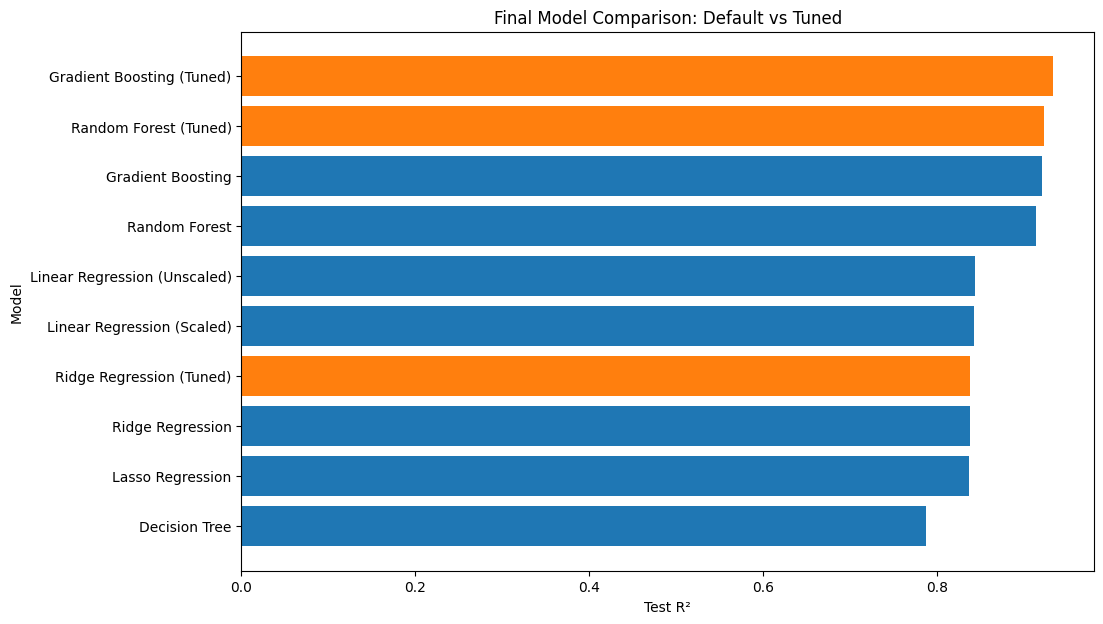

In [30]:
plot_df = final_results_df.sort_values("R2 Test", ascending=True)

color_map = {"Default": "tab:blue", "Tuned": "tab:orange"}
bar_colors = plot_df["Version"].map(color_map)

plt.figure(figsize=(11, 7))
plt.barh(plot_df["Model"], plot_df["R2 Test"], color=bar_colors)
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Final Model Comparison: Default vs Tuned")
plt.show()

In [31]:
best_model_name = final_results_df.loc[0, "Model"]
best_model = fitted_models[best_model_name]["model"]
best_X_test = fitted_models[best_model_name]["X_test"]
best_y_test_pred = fitted_models[best_model_name]["y_test_pred"]

print("Winning model:", best_model_name)
print(f"Best Test R²:  {final_results_df.loc[0, 'R2 Test']:.4f}")
print(f"Best Test RMSE:{final_results_df.loc[0, 'RMSE Test']:.4f}")

Winning model: Gradient Boosting (Tuned)
Best Test R²:  0.9331
Best Test RMSE:4.0616


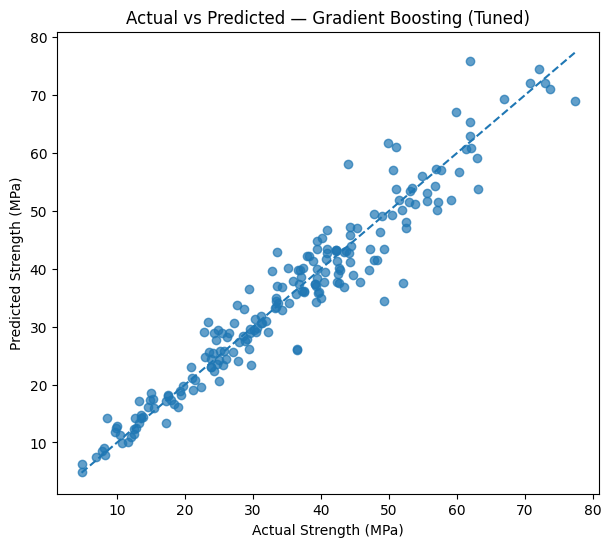

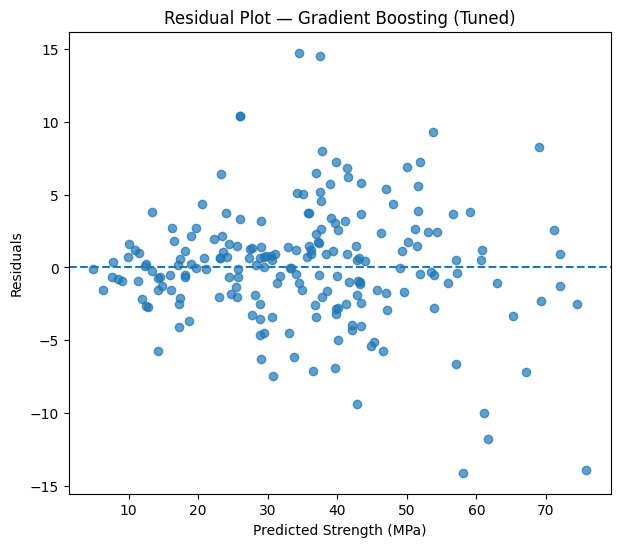

In [32]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.show()

residuals = y_test - best_y_test_pred

plt.figure(figsize=(7, 6))
plt.scatter(best_y_test_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

,Feature,Importance
27,binder_x_age,0.523433
10,water_binder_ratio,0.166291
25,cement_x_age,0.147215
3,water,0.043060
9,water_cement_ratio,0.025351
11,binder_minus_water,0.010689
6,fine_agg,0.010130
14,flyash_binder_ratio,0.007074
12,cement_binder_ratio,0.006122
15,sp_cement_ratio,0.006046


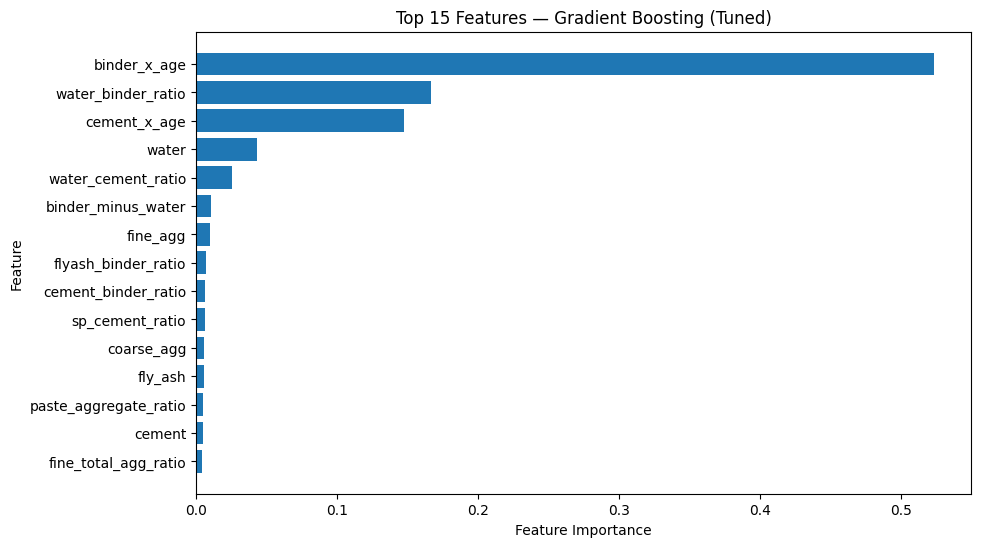

In [33]:
def plot_model_importance(model, feature_names, top_n=15):
    final_estimator = model.named_steps["model"] if hasattr(model, "named_steps") else model

    if hasattr(final_estimator, "feature_importances_"):
        importance_values = final_estimator.feature_importances_
        importance_label = "Feature Importance"
    elif hasattr(final_estimator, "coef_"):
        importance_values = np.abs(np.ravel(final_estimator.coef_))
        importance_label = "Absolute Coefficient"
    else:
        print("The winning model does not provide built-in feature importances or coefficients.")
        return

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance_values
        })
        .sort_values("Importance", ascending=False)
        .head(top_n)
        .sort_values("Importance", ascending=True)
    )

    display(importance_df.sort_values("Importance", ascending=False))

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Features — {best_model_name}")
    plt.show()

plot_model_importance(best_model, feature_names, top_n=15)

### Final Model Selection

The final winning model was **Gradient Boosting (Tuned)**. It achieved the highest test-set **R² of 0.9331** and the lowest **RMSE of 4.0616** among all models in the notebook. This improved on the best default model, **Gradient Boosting**, which had a test-set **R² of 0.9201** and **RMSE of 4.4399**. The tuned model therefore improved test-set R² by **0.0130** while also reducing prediction error.

This selection is also supported by cross-validation. **Gradient Boosting (Tuned)** achieved a cross-validation mean **R² of 0.9230** with a standard deviation of **0.0192**, indicating strong and stable performance across folds. Its training **R² was 0.9873**, producing a train-to-test gap of about **0.0542**, which suggests some increase in model complexity but not enough to outweigh its superior performance on unseen data.

In practical terms, the tuned Gradient Boosting model provides the most accurate and consistent predictions of concrete compressive strength for new concrete mixtures among all models tested in this notebook.

### 4.6 Save Best Model

The final selected model is saved with pickle so it can be reused outside this notebook. A verification step is included to confirm that the saved file loads correctly and can generate predictions on test data.

In [34]:
MODEL_PATH = "/content/models/best_model.pkl"

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_model, f)

final_estimator = best_model.named_steps["model"] if hasattr(best_model, "named_steps") else best_model

print("Saved model to:", MODEL_PATH)
print("Model type:", type(final_estimator).__name__)

if "best_params" in fitted_models[best_model_name]:
    print("Best parameters:", fitted_models[best_model_name]["best_params"])
else:
    print("Best parameters: Default model retained.")

Saved model to: /content/models/best_model.pkl
Model type: GradientBoostingRegressor
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}


In [35]:
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)

verification_X = best_X_test.iloc[:5].copy()
verification_preds = loaded_model.predict(verification_X)

verification_df = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": np.round(verification_preds, 2)
}, index=verification_X.index)

display(verification_df)

,Actual,Predicted
935,29.41,26.08
387,51.02,61.04
41,43.70,43.08
151,73.70,71.12
477,23.35,30.83


### Key Findings Summary

1. The best default model was **Gradient Boosting**, which achieved a test-set **R² of 0.9201** and a test-set **RMSE of 4.4399**.
2. The clearest overfitting pattern was observed in the **Decision Tree**, where training **R² = 0.9879** but test **R² = 0.7872**, a gap of approximately **0.2007**.
3. The strongest cross-validation result came from **Gradient Boosting**, with a mean CV **R² of 0.9112** and a standard deviation of **0.0187**.
4. **Gradient Boosting (Tuned)** was the **final winning model**, achieving the notebook’s **highest test-set R² (0.9331)** and **lowest RMSE (4.0616)**. It outperformed the best default model, **Gradient Boosting**, by **0.0130 R² points** and reduced **RMSE from 4.4399 to 4.0616**.
5. The saved winning model successfully reloaded and generated predictions for the first five test rows, confirming that the model export and verification process worked correctly.